# Inequality in Educational Opportunity - Data Analysis and Modeling

In this notebook, we will analyze the prepared education dataset to explore inequality in educational opportunities across different socioeconomic factors. We will perform exploratory data analysis (EDA), visualize trends, and build predictive model, to understand the impact of various factors on high school student performance. Then we will add additional variables to improve model performance.

## Project Overview
This project addresses inequality of educational opportunity in U.S. high schools. Here we will focus on average student performance on the ACT or SAT exams that students take as part of the college application process.

We expect a range of school performance on these exams, but is school performance associated with socioeconomic factors?



# Import libraries

We will import the necessary libraries for data analysis, visualization, and modeling.

In [73]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")
sns.set_palette('deep')

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

## Load the data

Load the prepared education dataset for analysis.

In [74]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/JLichwa80/education/refs/heads/master/data/education_data_cleaned.csv'
)

In [75]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


# Exploratory data analysis

Explore the dataset to understand the distribution of variables, identify patterns, and visualize relationships between socioeconomic factors and student performance.

### Examine distributions and relationships



We will plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables.

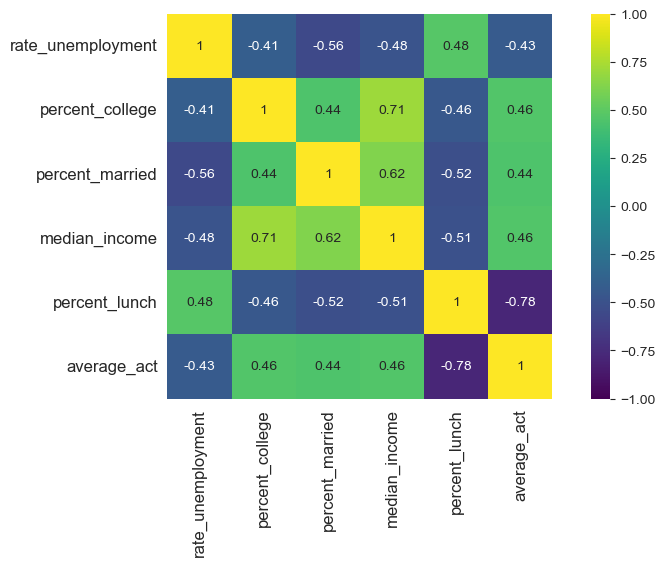

In [76]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch', 'state', 'charter']

numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors + ["average_act"]].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

We can see that the strongest correlations with ACT/SAT scores is percent of free lunch, similar like we identified during data preparation. Other factors show moderate correlations, indicating multiple influences on student performance.

Next we will show pair plots to explore relationships between the variables. We will differentiate regression lines by charter school status to see if there are differences in trends.

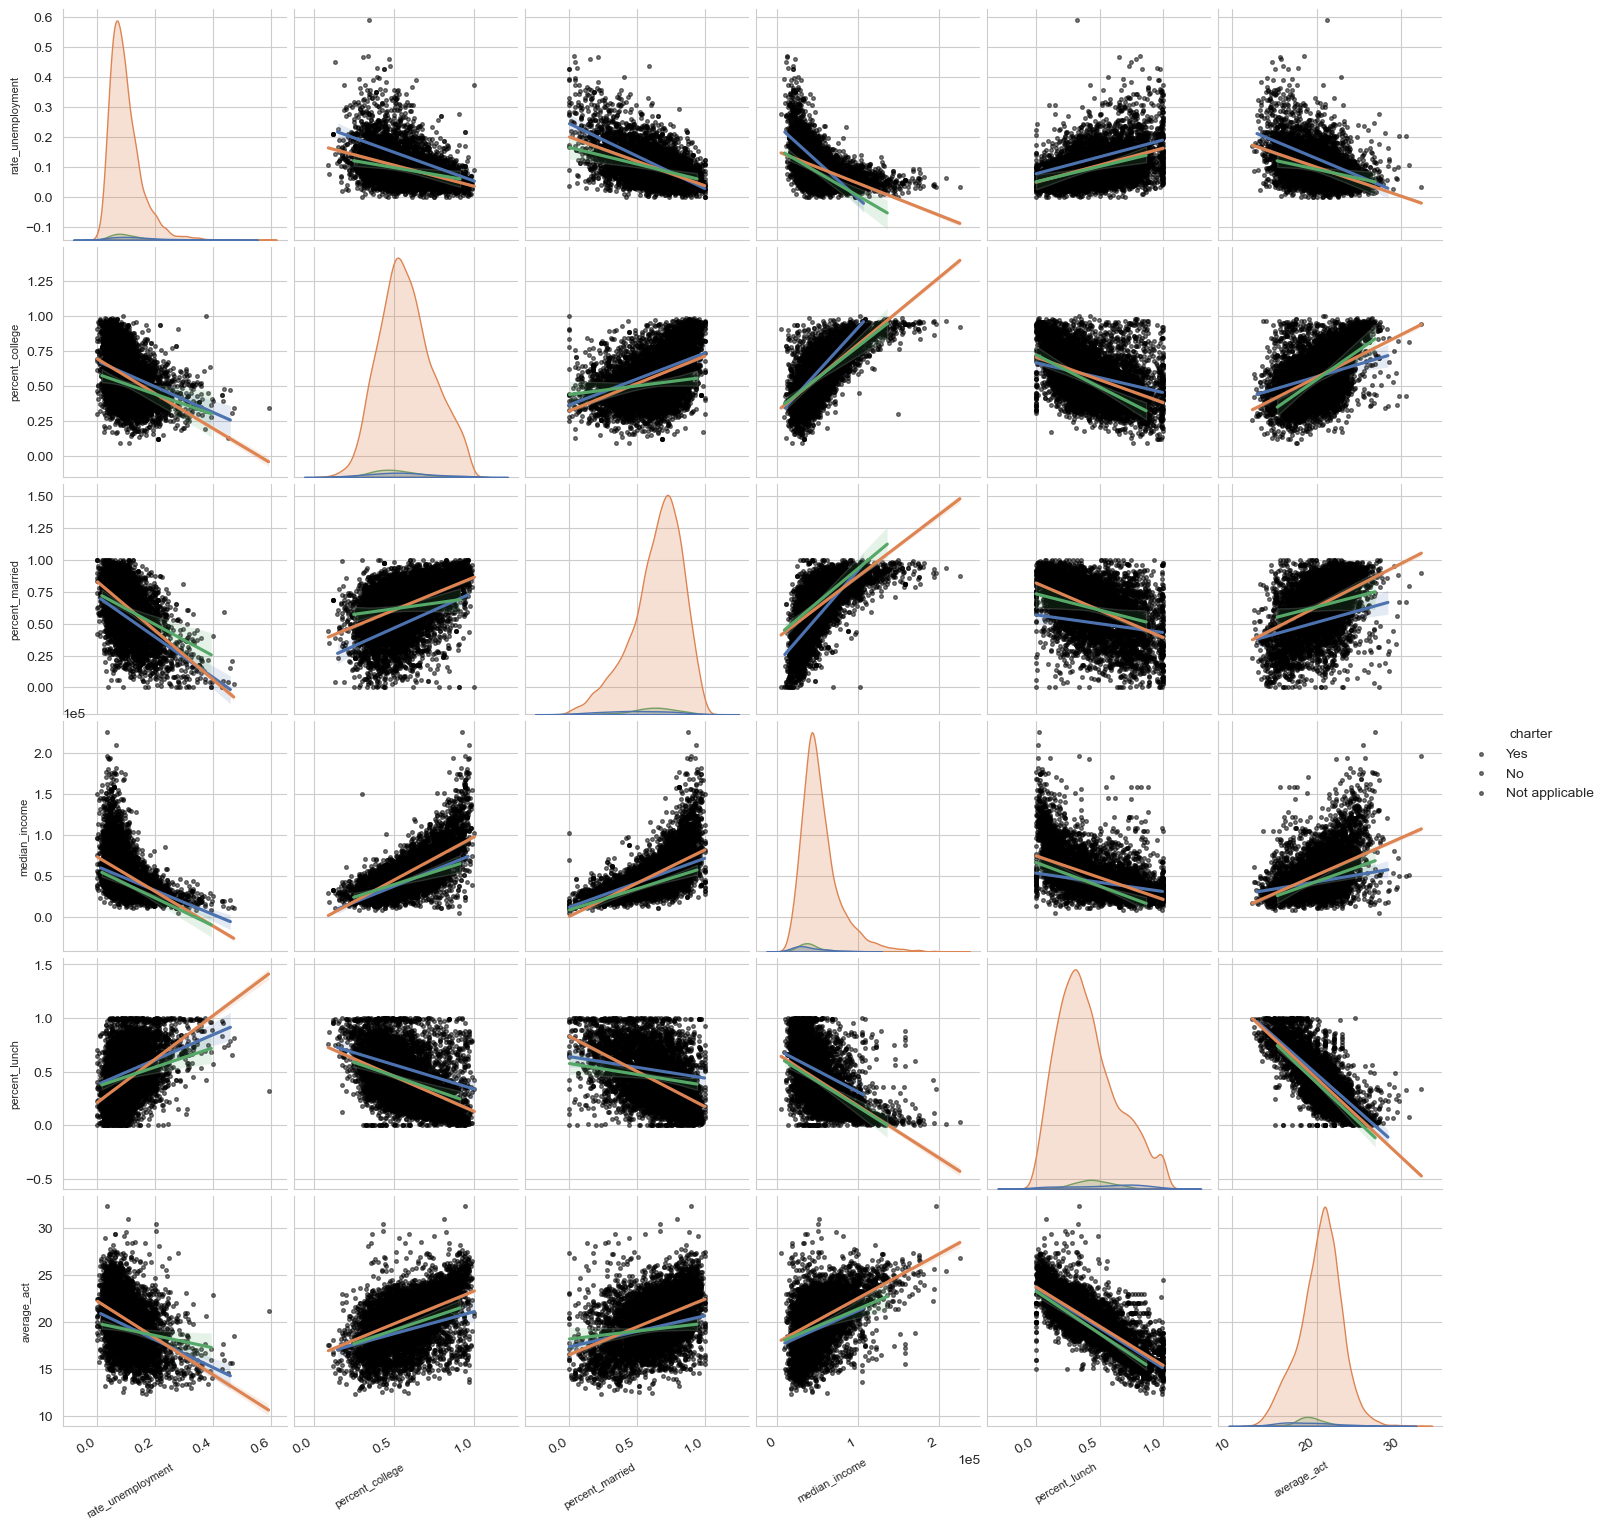

In [77]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'median_income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    if ax.get_ylabel() == 'median_income':
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

We can notice small differences in trends between charter and non-charter schools, but overall the relationships are similar. We can also see correlation between predictor variables, such as median income and percent of free lunch which means that not all predictors will be required in the model. Distributions plots show that some variables have skewed distributions, which may require transformation for modeling.

### Identify outliers

We can use the interquartile range to identify outliers. This is also evident in boxplots of the data. Median income is on a very different scale than the other predictors, so we will make two plots to explore the data.

#### Numerical predictors minus median income boxplots

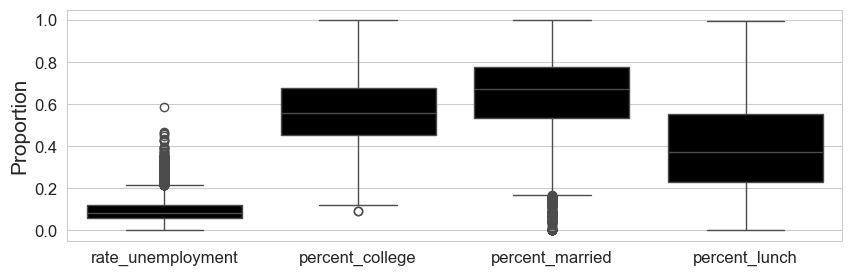

In [78]:
plt.figure(figsize=(10,3))

fractions = list(numerical_predictors)
fractions.remove('median_income')

sns.boxplot(data=df[fractions], color='k')

plt.ylabel('Proportion', fontsize=15)

plt.tick_params(labelsize=12)

plt.show()

From above plot we can notice most outliers in rate of unemployment and percent of married, with rate of unemplotyment having many outliers above the upper whisker and percent of married having many outliers below the lower whisker.

#### Median income boxplot

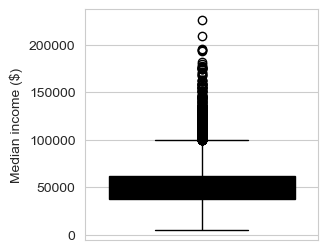

In [79]:
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='median_income', color='k')

plt.ylabel('Median income ($)')

plt.show()

Median income three quantile range is around 50,000 with outliers going up to nearly 300,000, idicating a large spread in income levels across the schools.

## Summary

1.  The numerical predictors are related to `average_act`. The relationships appear roughly linear.

2.  The numerical predictors are correlated with each other, suggesting that not all predictors will be necessary.

3.  Some variables have skewed distributions, suggesting that transformations of input variables might be useful.

4. There are outliers in `rate_unemployment`, `percent_college`, `percent_married` and `median_income`. None of these are obviously incorrect values; they likely reflect skewed distributions. We may consider applying something like a log transformation to these predictors as we explore different models.

5. The relationships are similar across charter and non-charter schools, but might be significantly different.

# Modeling

In this section, we will explore different modeling approaches to predict average ACT/SAT scores based on socioeconomic factors. We will start with a baseline linear regression model and then experiment with more complex models. We will evaluate model performance using appropriate metrics.

### Single input models

Fit and assess models predicting the average ACT score from each of the input variables. 

#### Median income

We will start with evaluating meadian income as a single predictor for average ACT/SAT scores.

##### Plot the regression line and the scatter plot

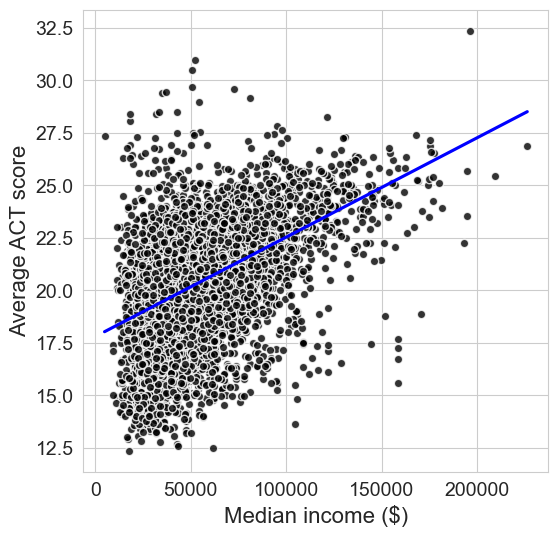

In [80]:
plt.figure(figsize=(6, 6))

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Median income ($)', fontsize=16)
plt.ylabel('Average ACT score', fontsize=16)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

As we saw in the exploratory data analysis, there is visible relationship between median income and average ACT/SAT scores.

##### Fit the simple linear regression model

Here we will fit the simple linear regression model using median income as the predictor and print the model summary on how well median income predicts average ACT scores.

In [81]:
model_median_income = smf.ols(formula='average_act ~ median_income', data=df).fit()
print(model_median_income.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     1936.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        00:57:57   Log-Likelihood:                -16000.
No. Observations:                7211   AIC:                         3.200e+04
Df Residuals:                    7209   BIC:                         3.202e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        17.8012      0.063    284.680

In OLS report the most imporant to look at is P-value, which describes statistical significance of the predictor, and R-square, which describe percentage of variance in target variable which can be descibed by predictor. 
From above model summary we can see that median income is statistically significant predictor of average ACT/SAT scores (p-value < 0.05) and explains about 21.2% of the variance in average ACT/SAT scores (R-squared = 0.212).


##### Numerical assessment of fit accuracy

Compute the R-squared

In [82]:
model_median_income.rsquared

np.float64(0.21171593201641203)

Compute the RMSE

In [83]:
y_hat = model_median_income.predict()

In [84]:
np.sqrt(mean_squared_error(df['average_act'], y_hat)).round(3)

ValueError: Found input variables with inconsistent numbers of samples: [7227, 7211]

Compute the mean absolute error

In [ ]:
mean_absolute_error(df['average_act'], y_hat)

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

In [ ]:
plt.figure(figsize=(6, 6))

plt.plot(y_hat, model_median_income.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Try a quadratic model. Plot the regression curves and the scatter plot

In [ ]:
plt.figure(figsize=(6, 6))

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            order=2,
            color='orange',
            ci=False,
            scatter=False)

# Add axis labels
plt.xlabel('Median income ($)', fontsize=16)
plt.ylabel('Average ACT score', fontsize=16)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Fit a quadratic linear regression model

In [ ]:
model_median_income2 = smf.ols(
    formula='average_act ~ median_income + I(median_income**2)',
    data=df).fit()

<pre>
























</pre>

##### Display the fit summary

In [ ]:
print(model_median_income2.summary())

<pre>
























</pre>

##### Assess the model significance

In [ ]:
model_median_income2.pvalues

In [ ]:
anova_lm(model_median_income, model_median_income2)

<pre>
























</pre>

##### Assess the model accuracy

Compute the mean absolute error

In [ ]:
mean_absolute_error(df['average_act'], model_median_income2.predict())

<pre>
























</pre>

##### Compare the quadratic model accuracy to the first order model

In [ ]:
mean_absolute_error(df['average_act'], model_median_income2.predict())

In [ ]:
mean_absolute_error(df['average_act'], model_median_income.predict())

<pre>
























</pre>

#### Unemployment rate

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(data=df,
            x='rate_unemployment',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1}
)

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [ ]:
model_ru = smf.ols(formula='average_act ~ rate_unemployment', data=df).fit()

In [ ]:
print(model_ru.summary())

The model is significant, but it is not great. The $R^2 = 0.19$, which is low.

Make a residual plot to assess the model.

In [ ]:
plt.figure(figsize=(6,6))

# residual plot
sns.residplot(data=df,
              x = 'rate_unemployment',
              y = 'average_act',
              scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score residual', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

Test whether a quadratic model is better.

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(x='rate_unemployment',
            y='average_act',
            color='blue',
            data=df,
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(x='rate_unemployment',
            y='average_act',
            color='orange',
            order = 2,
            data=df,
            ci=False,
            scatter=False)

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [ ]:
model_ru2 = smf.ols(formula='average_act ~ rate_unemployment + I(rate_unemployment**2)', data=df).fit()

In [ ]:
df.head()

In [ ]:
print(model_ru2.summary())

A quadratic model is significant, but it does not improve the fit by much.

In [ ]:
anova_lm(model_ru, model_ru2)

**Build a single input model for one of the other predictors**

#### Percent of adults with a college degree

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='percent_college',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent college', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [ ]:
model_pc = smf.ols(formula='average_act ~ percent_college', data=df).fit()

In [ ]:
print(model_pc.summary())

The model is significant, but it is not great. The $R^2 = 0.20$, which is low.

#### Percent of adults married

In [ ]:
plt.figure(figsize=(8,6))


sns.regplot(data=df,
            x='percent_married',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent married', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [ ]:
model_pm = smf.ols(formula='average_act ~ percent_married', data=df).fit()

In [ ]:
print(model_pm.summary())

The model is significant, but it is not great. The $R^2 = 0.20$, which is low.

#### Percent of students with free or reduced price lunch

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='percent_lunch',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent free or reduced price lunch', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [ ]:
model_pl = smf.ols(formula='average_act ~ percent_lunch', data=df).fit()

print(model_pl.summary())

There is a strong negative linear relationship between the percent of students with free or reduced price lunch and the average ACT score ($R^2 = 0.61$).

<pre>
























</pre>

# Multiple linear regression

Fit the multiple linear regression model using all socioeconomic variables as predictors.

In [ ]:
model = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_married + median_income + percent_lunch',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [ ]:
print(model.summary())

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

In [ ]:
y_hat = model.predict()

In [ ]:
plt.figure(figsize=(5, 5))

plt.plot(y_hat, model.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Compute the mean absolute error

In [ ]:
mean_absolute_error(df['average_act'], model.predict())

<pre>
























</pre>

## Summary

1. The multiple linear regression model with all socioeconomic predictors can predict ACT scores with an average error of roughly 1 point using these predictors.

2. The residual plot suggests that there will be limited improvement from adding transformations of these predictors.

3. Not all predictors have significant coefficients.

4. Adding predictors to the model may improve the performance.

<pre>
























</pre>

# Fit a reduced model with the significant predictors

In [ ]:
model_reduced = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [ ]:
print(model_reduced.summary())

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

In [ ]:
y_hat = model_reduced.predict()

In [ ]:
plt.figure(figsize=(5, 5))

plt.plot(y_hat, model_reduced.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Compute the mean absolute error

In [ ]:
mean_absolute_error(df['average_act'], model_reduced.predict())

<pre>
























</pre>

##### Compare the accuracy between full and reduced models

In [ ]:
mae_full = mean_absolute_error(df['average_act'], model.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

r2_full = model.rsquared
r2_reduced = model_reduced.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_full, mae_reduced],
              'R-squared': [r2_full, r2_reduced]},
              index=['full model', 'reduced model']).round(4)

<pre>
























</pre>

##### Use an ANOVA to test the significance of difference between models

In [ ]:
anova_lm(model_reduced, model)

<pre>
























</pre>

## Summary

1. The model predicting the average ACT score from `rate_unemployment`, `percent_college` and, `percent_lunch` is not significantly different than the model with all five socioeconomic variables as predictors.

2. Adding predictors to the model may improve the performance.

3. We have not yet determined the relative importance of each predictor in the model.

<pre>
























</pre>

# Add charter school status as a predictor

In [ ]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

Create a model where the intercept can vary between schools based on charter school status

In [ ]:
model_charter = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch + C(charter)',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [ ]:
print(model_charter.summary())

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(y_hat, model_charter.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Compute the mean absolute error

In [ ]:
mean_absolute_error(df['average_act'], model_charter.predict())

<pre>
























</pre>

##### Create a model where the intercept and slope can vary between schools based on charter school status

In [ ]:
model_charter2 = smf.ols(formula='average_act ~ (rate_unemployment + percent_college + percent_lunch) * C(charter)', data=df).fit()

<pre>
























</pre>

##### Print the summary

In [ ]:
print(model_charter2.summary())

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(y_hat, model_charter2.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Use an ANOVA to test the significance of difference between models

In [ ]:
anova_lm(model_charter, model_charter2)

<pre>
























</pre>

##### Compute the mean absolute error

In [ ]:
mean_absolute_error(df['average_act'], model_charter2.predict())

Compare to the intercept model

In [ ]:
mean_absolute_error(df['average_act'], model_charter.predict())

<pre>
























</pre>

## Try a limited model using predictors with significant coefficients

##### Create a design matrix with all precitors

In [ ]:
from patsy import dmatrices

In [ ]:
y, X_design = dmatrices('average_act ~ (rate_unemployment + percent_college + percent_lunch) * C(charter)',
                        data=df,
                        return_type='dataframe'
                        )

In [ ]:
X_design.head()

<pre>
























</pre>

##### Keep only significant predictors from the full model

In [ ]:
X = X_design.loc[:, model_charter2.pvalues<0.05]

print(X.columns)

<pre>
























</pre>

##### Fit the model

In [ ]:
model_charter3 = sm.OLS(y, X).fit()

<pre>
























</pre>

##### Print the summary

In [ ]:
print(model_charter3.summary())

<pre>
























</pre>

##### Compute the mean absolute error

In [ ]:
mean_absolute_error(df['average_act'], model_charter3.predict())

In [ ]:
mean_absolute_error(df['average_act'], model_charter2.predict())

In [ ]:
mean_absolute_error(df['average_act'], model_charter.predict())

<pre>
























</pre>

## Summary

1. Whether a school is a charter school or not can have a statistically significant, but practically small impact on the model.

<pre>
























</pre>

While a scaling transformation is not required for multiple linear regression models, scaling helps us to interpret the relative importance of each predictor based on the magnitude of the estimated coefficients.

# Scaling

##### Scale the predictor variables in the reduced model to have mean 0 and standard deviation 1 and add them to the data frame

In [ ]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_lunch']

In [ ]:
scaled_columns = [var + '_normalized' for var in predictor_variables]

print(scaled_columns)

In [ ]:
scaler = StandardScaler().fit(df[predictor_variables])

In [ ]:
df[scaled_columns] = scaler.transform(df[predictor_variables])

<pre>
























</pre>

##### Check the mean and standard deviation of the transformed data.

In [ ]:
df[scaled_columns].agg(['mean', 'std']).round(3)

<pre>
























</pre>

##### Fit the multiple linear regression model with the normalized predictors

In [ ]:
model_normalized = smf.ols(
    formula='average_act ~ rate_unemployment_normalized + percent_college_normalized + percent_lunch_normalized',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [ ]:
print(model_normalized.summary())

<pre>
























</pre>

##### Compare the accuracy between the original and normalized models

In [ ]:
mae_normalized = mean_absolute_error(df['average_act'], model_normalized.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

r2_normalized = model_normalized.rsquared
r2_reduced = model_reduced.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_normalized, mae_reduced],
              'R-squared': [r2_normalized, r2_reduced]},
              index=['normalized model', 'reduced model']).round(4)

<pre>
























</pre>

## Summary

1. The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis.

<pre>
























</pre>

# Conclusion

The analysis shows that college entrance test scores (ACT and SAT) are related to socioeconomic variables.

In particular, using only the percent of students at a school receiving free or reduced price lunch, we can predict ACT scores to within a single point, on average.

The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis. It was also the only variable measured for students at the school, rather than for the neighborhood. It is an open question how important the other predictors would be if they were measured for the students at the school, rather than for the neighborhood.

